In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score as r2
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from google.colab import files
data = files.upload()

Saving Copy of Shoe prices.csv to Copy of Shoe prices.csv


In [ ]:
file_path = 'Copy of Shoe prices.csv'
data = pd.read_csv(file_path)

In [ ]:
data.head()

,Brand,Model,Type,Gender,Size,Color,Material,Price (USD)
0,Nike,Air Jordan 1,Basketball,Men,US 10,Red/Black,Leather,$170.00
1,Adidas,Ultra Boost 21,Running,Men,US 9.5,Black,Primeknit,$180.00
2,Reebok,Classic Leather,Casual,Men,US 11,White,Leather,$75.00
3,Converse,Chuck Taylor,Casual,Women,US 8,Navy,Canvas,$55.00
4,Puma,Future Rider,Lifestyle,Women,US 7.5,Pink,Mesh,$80.00


In [ ]:
data.columns

Index(['Brand', 'Model', 'Type', 'Gender', 'Size', 'Color', 'Material',
       'Price (USD)'],
      dtype='object')

In [ ]:
input_columns = ['Brand', 'Model', 'Type', 'Gender', 'Size', 'Color', 'Material']

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Brand        1006 non-null   object
 1   Model        1006 non-null   object
 2   Type         1006 non-null   object
 3   Gender       1006 non-null   object
 4   Size         1006 non-null   object
 5   Color        1006 non-null   object
 6   Material     1006 non-null   object
 7   Price (USD)  1006 non-null   object
dtypes: object(8)
memory usage: 63.0+ KB


In [ ]:
#Remove $
data['Price (USD)'] = data['Price (USD)'].str.replace('^\$', '', regex=True).str.strip().astype('float')

In [ ]:
#Encode categorical variables
input_columns = ['Brand', 'Model', 'Type', 'Gender', 'Size', 'Color', 'Material']
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoder_features = encoder.fit_transform(data[input_columns])

#Convert the encoded features to a dataframe
encoder_df = pd.DataFrame(encoder_features, columns=encoder.get_feature_names_out(input_columns))

#Create Price Column
encoder_df['Price (USD)'] = data['Price (USD)']

#Split Training and testing
X = encoder_df.drop(columns=['Price (USD)'],axis = 1)
y = encoder_df['Price (USD)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#Initialize the Models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

#Train the Models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = y_pred
    mse, r2_value = mean_squared_error(y_test, y_pred), r2(y_test, y_pred)
    # Convert scientific notation to decimal
    mse_decimal = float('{:.10f}'.format(mse))

    # Convert decimal to integer (rounding)
    mse_integer = round(mse_decimal)
    results[name] = {'MSE': mse_integer, 'R2 Score': r2_value}
    print(f"{name} -> (MSE:{mse_integer}, R2: {r2_value:.2})")

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Linear Regression -> (MSE:1417371803423645576038711296, R2: -9.5e+23)
Decision Tree -> (MSE:232, R2: 0.84)
Random Forest -> (MSE:234, R2: 0.84)
Gradient Boosting -> (MSE:261, R2: 0.83)
SVR -> (MSE:1072, R2: 0.28)


***Data Visualtions***


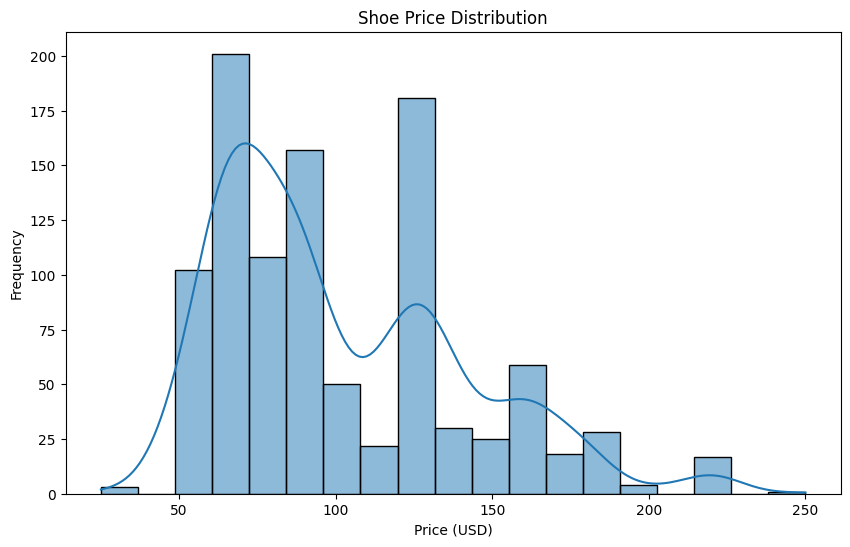

In [ ]:
#Shoe Price Distribution
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(data['Price (USD)'], kde= True)
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.title('Shoe Price Distribution')
plt.show()

Text(0.5, 1.0, 'Average Price by Brand')

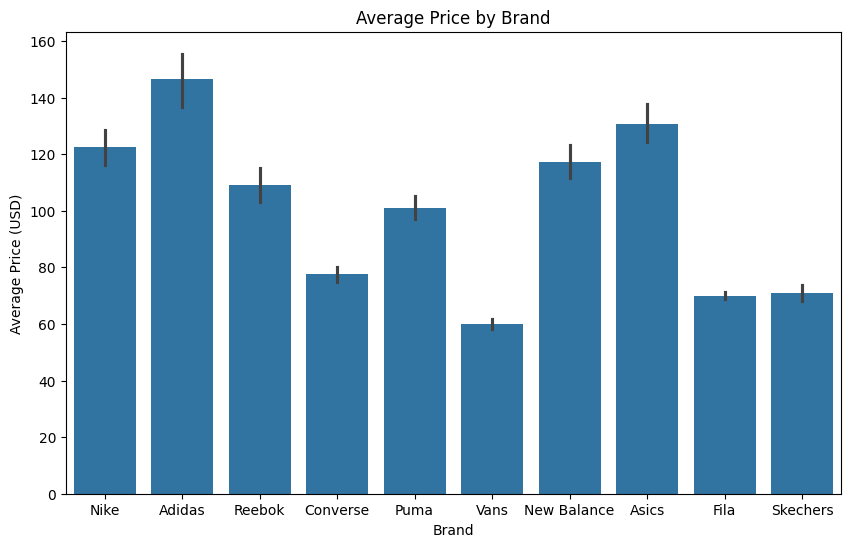

In [ ]:
#Plot Brand Vs Avg. price
plt.figure(figsize=(10, 6))
sns.barplot(x='Brand', y='Price (USD)', data=data)
plt.xlabel('Brand')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Brand')

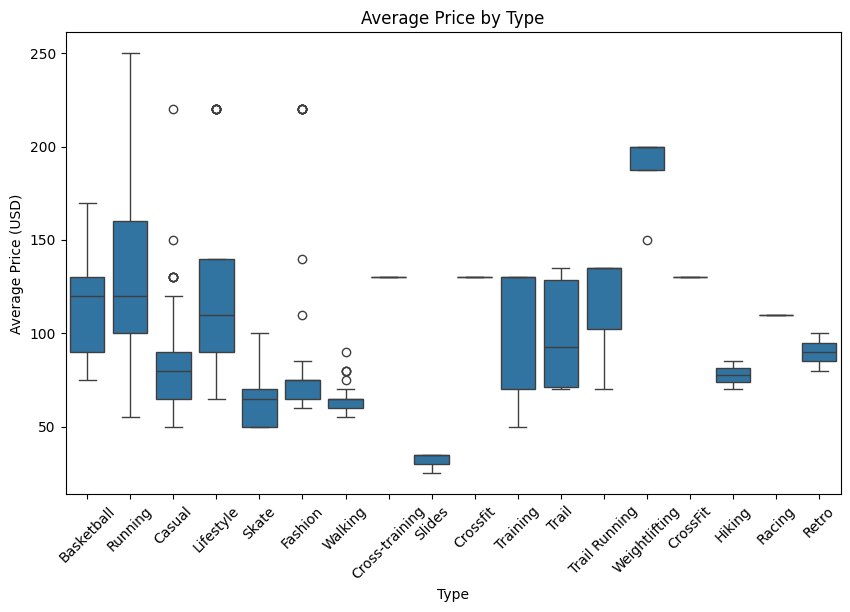

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Price (USD)', data=data)
plt.xlabel('Type')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Type')
plt.xticks(rotation=45)
plt.show()

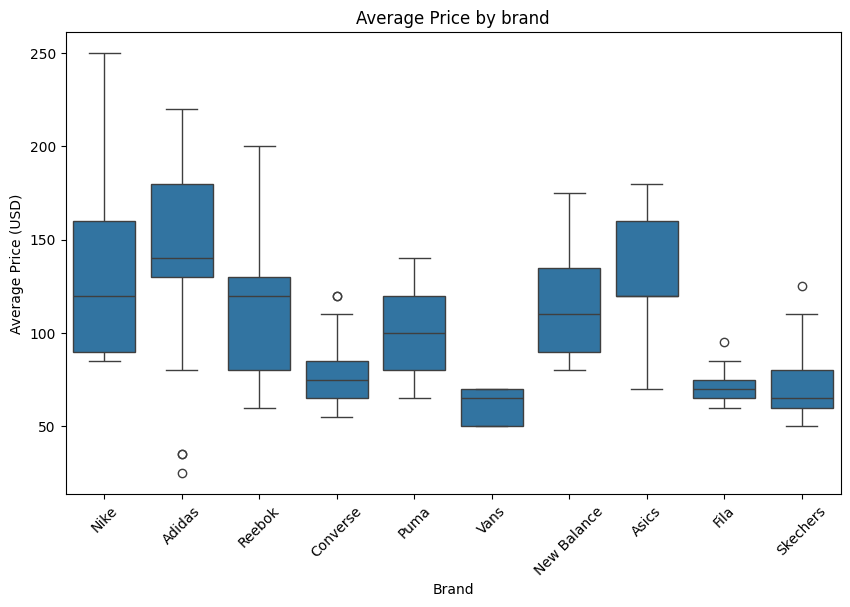

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Brand', y='Price (USD)', data=data)
plt.xlabel('Brand')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by brand')
plt.xticks(rotation=45)
plt.show()

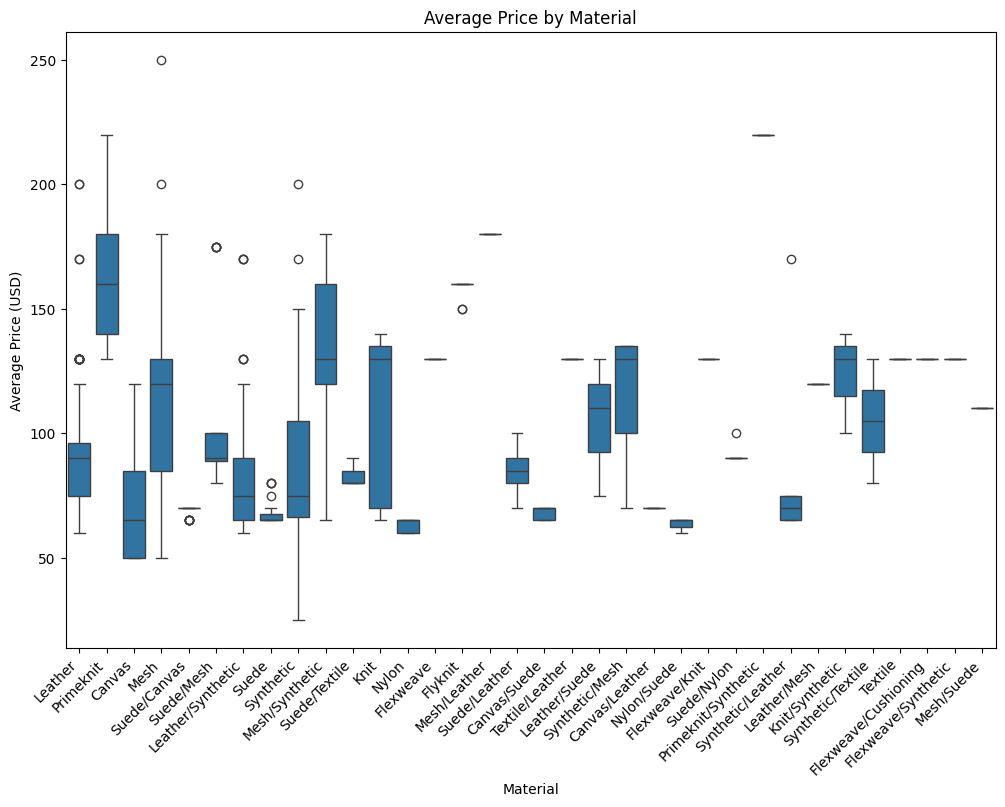

In [ ]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='Material', y='Price (USD)', data=data)
plt.xlabel('Material')
plt.ylabel('Average Price (USD)')
plt.title('Average Price by Material')
plt.xticks(rotation=45, ha = "right")
plt.show()

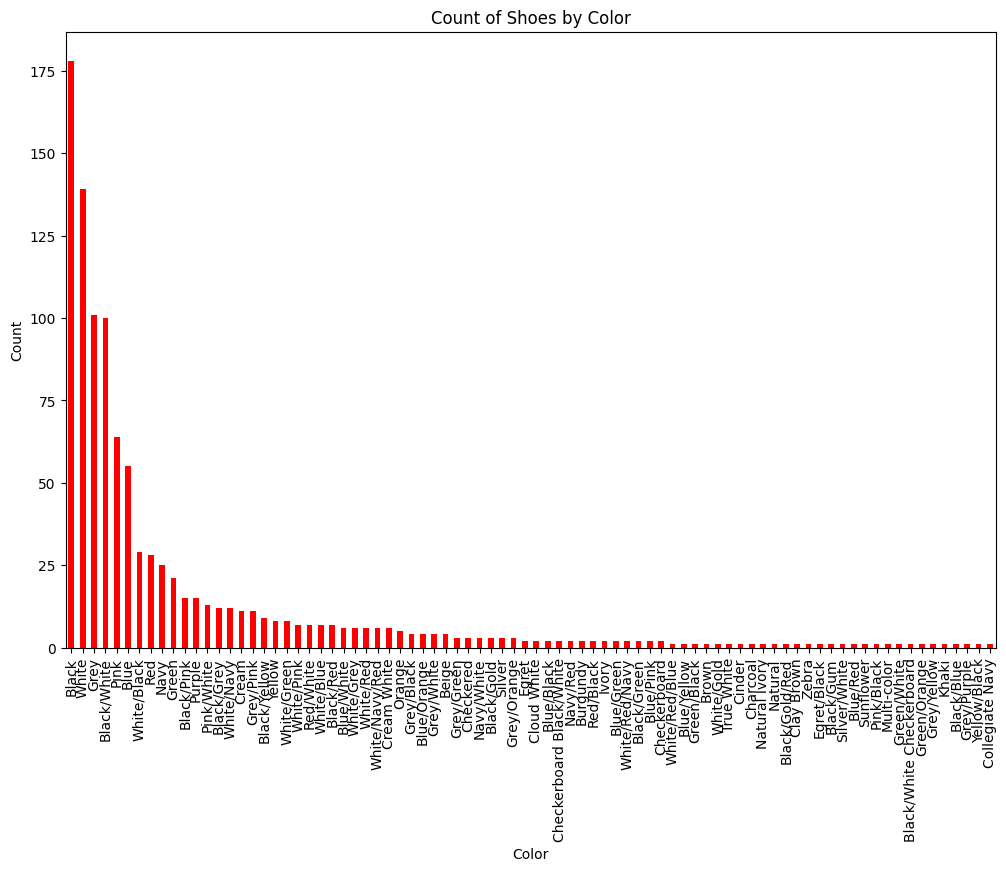

In [ ]:
#Count the shoes by color
plt.figure(figsize=(12, 8))
data['Color'].value_counts().plot(kind='bar', color = "red")
plt.xlabel('Color')
plt.ylabel('Count')
plt.title('Count of Shoes by Color')
plt.show()

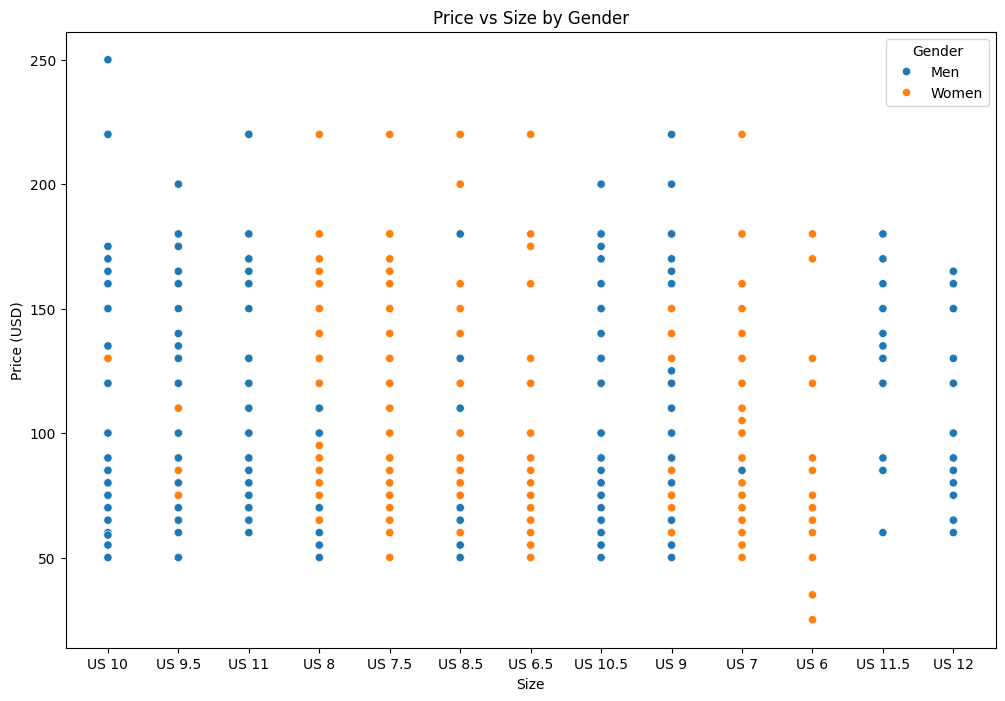

In [ ]:
#Show the Scatterplot of price against size, colored by gender
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Size', y='Price (USD)', hue='Gender', data=data)
plt.xlabel('Size')
plt.ylabel('Price (USD)')
plt.title('Price vs Size by Gender')
plt.show()

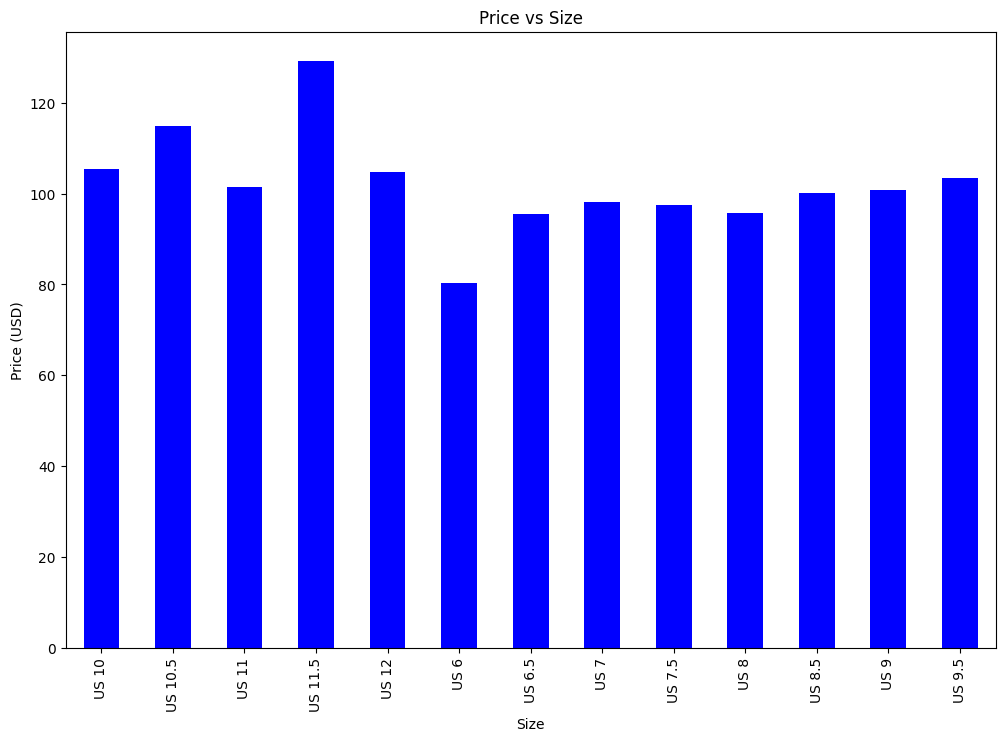

In [ ]:
#Show the Scatterplot of price against size, colored by gender
plt.figure(figsize=(12, 8))
size_avg_price = data.groupby('Size')['Price (USD)'].mean().sort_index()
size_avg_price.plot(kind='bar', color = "blue")
plt.xlabel('Size')
plt.ylabel('Price (USD)')
plt.title('Price vs Size')
plt.show()

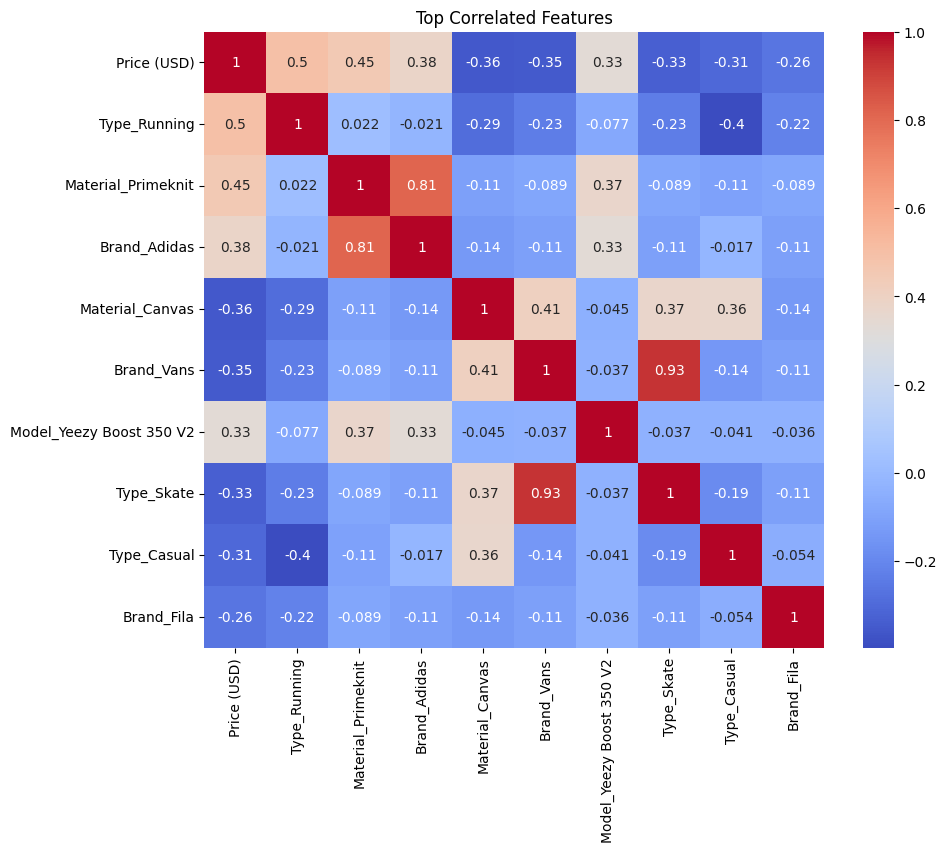

In [ ]:
#Heat Map showing top correlated features
#Calculate Correlation Matrix
correlation_matrix = encoder_df.corr()
#Get the top correlated feautres with price
top_correlated_features = correlation_matrix['Price (USD)'].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize = (10, 8))
sns.heatmap(encoder_df[top_correlated_features].corr(), annot=True, cmap='coolwarm')
plt.title('Top Correlated Features')
plt.show()

***Results***

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Linear Regression Mean Squared Error: 1.4173718034236456e+27
Decision Tree Mean Squared Error: 257.32591496149615
Random Forest Mean Squared Error: 224.22584954511737
Gradient Boosting Mean Squared Error: 262.8348591266825
SVR Mean Squared Error: 1072.4046156397167


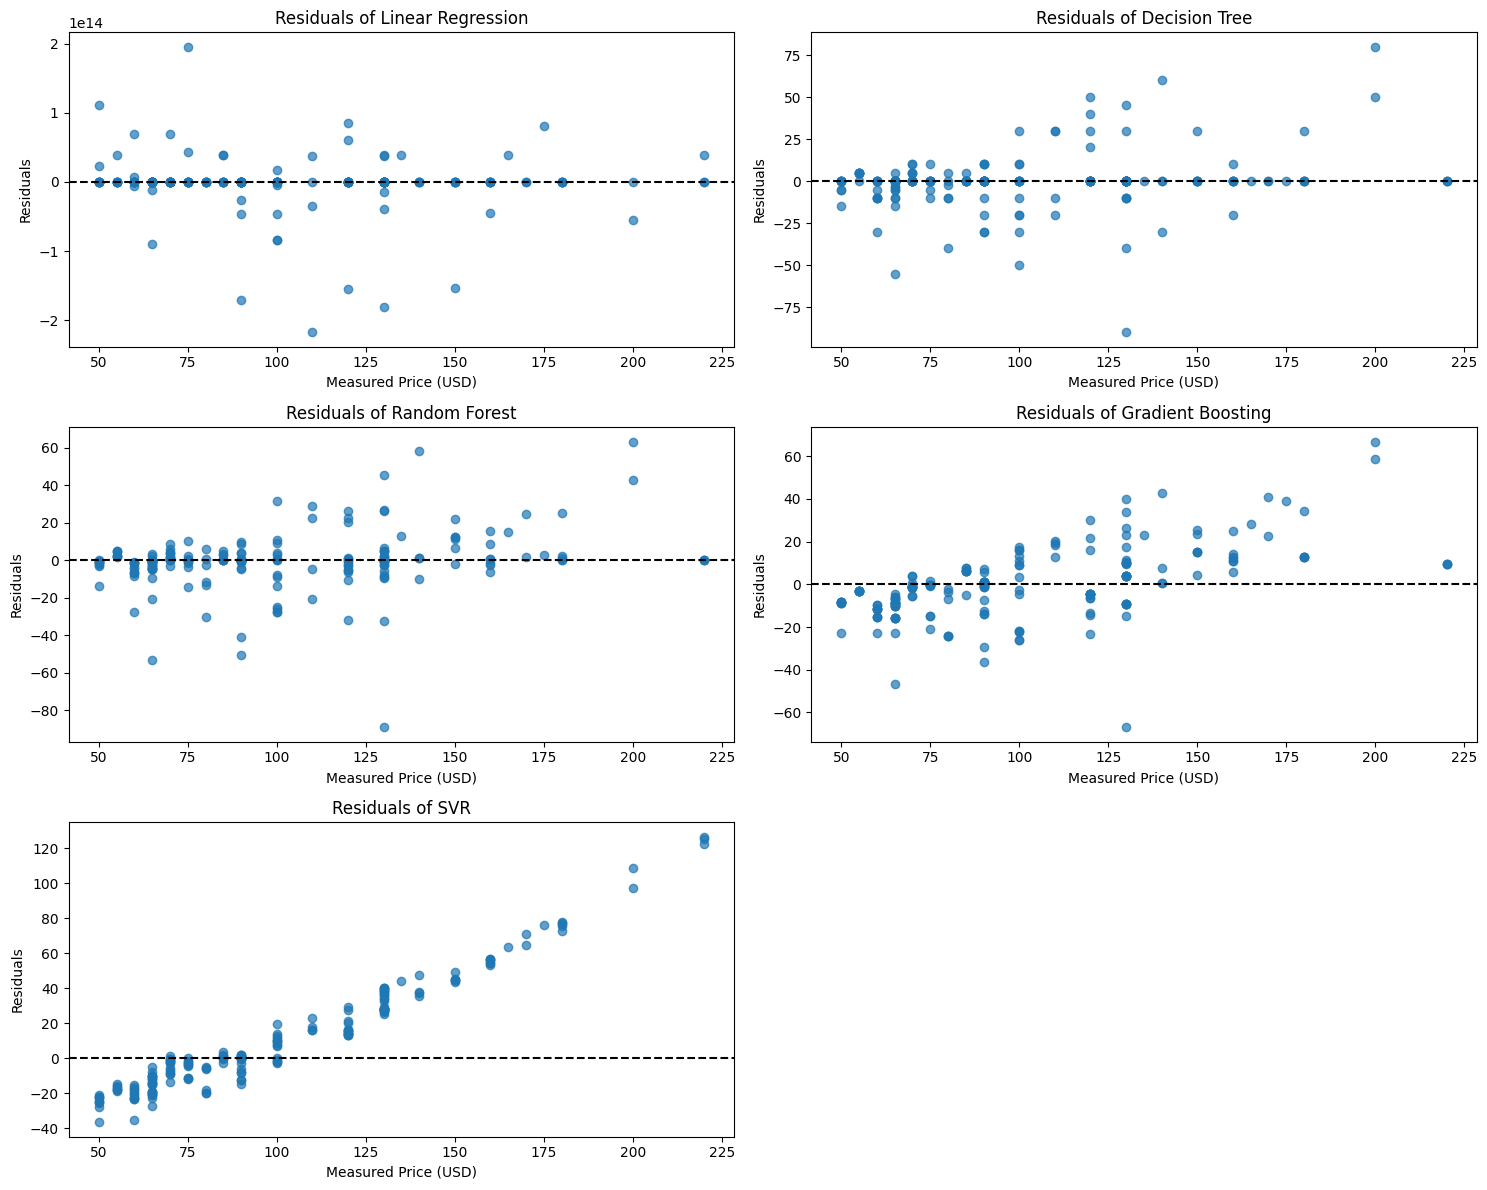

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
# Assuming the DataFrame is already loaded into 'data'
# Clean the 'Price (USD)' column
data['Price (USD)'] = data['Price (USD)'].replace('[\$,]', '', regex=True).astype(float)
# Encode categorical variables using OneHotEncoder
categorical_columns = ['Brand', 'Model', 'Type', 'Gender', 'Size', 'Color', 'Material']
encoder = OneHotEncoder(sparse=False)
encoded_features = encoder.fit_transform(data[categorical_columns])
# Convert the encoded features to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))
# Combine encoded features with the 'Price (USD)' column
encoded_df['Price (USD)'] = data['Price (USD)']
# Split the data into training and testing sets
X = encoded_df.drop('Price (USD)', axis=1)
y = encoded_df['Price (USD)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}
# Dictionary to hold predictions
predictions = {}
# Train and evaluate models, storing predictions
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} Mean Squared Error: {mse}")
# Define number of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()
# Plot Residuals for each model
for idx, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test - y_pred
    axes[idx].scatter(y_test, residuals, alpha=0.7)
    axes[idx].axhline(y=0, color='black', linestyle='--')
    axes[idx].set_xlabel('Measured Price (USD)')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'Residuals of {name}')
# Hide the empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()



In [ ]:
label_encoder = LabelEncoder()
#data['Brand'] = label_encoder.fit_transform(data['Brand'])
data['Model'] = label_encoder.fit_transform(data['Model'])
data['Type'] = label_encoder.fit_transform(data['Type'])
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Size'] = label_encoder.fit_transform(data['Size'])
data['Color'] = label_encoder.fit_transform(data['Color'])
data['Material'] = label_encoder.fit_transform(data['Material'])

KeyError: 'Model'

In [ ]:
# Check dataset content and unique entries
print(data.head())
#print("Brands:", data['Brand'].unique())
#print("Models:", data['Model'].unique())

# Manual mapping of known textual entries (if necessary)
brand_map = {'Nike': 1, 'Adidas': 2, 'Asics': 3, 'Converse': 4, 'Fila': 5, 'New Balance': 6,'Puma': 7,'Reebok': 8,'Skechers': 9,'Vans': 10 }  # Replace 'Other' entries manually if needed
data['Brand'] = data['Brand'].map(brand_map)


      Brand            Model        Type Gender    Size      Color   Material  \
0      Nike     Air Jordan 1  Basketball    Men   US 10  Red/Black    Leather   
1    Adidas   Ultra Boost 21     Running    Men  US 9.5      Black  Primeknit   
2    Reebok  Classic Leather      Casual    Men   US 11      White    Leather   
3  Converse     Chuck Taylor      Casual  Women    US 8       Navy     Canvas   
4      Puma     Future Rider   Lifestyle  Women  US 7.5       Pink       Mesh   

  Price (USD)  
0    $170.00   
1    $180.00   
2     $75.00   
3     $55.00   
4     $80.00   


In [ ]:
# Check unique values for columns
print("Updated brands after mapping:", data['Brand'].unique())

Updated brands after mapping: [ 1  2  8  4  7 10  6  3  5  9]


In [ ]:
# One-hot encode the 'Model' column if necessary
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(data[['Model']])
X_categorical_df = pd.DataFrame(X_categorical, columns=encoder.get_feature_names_out(['Model']))

# Merging back into main frame
data = pd.concat([X_categorical_df, data.drop(columns=['Model'])], axis=1)



/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
 #One-hot encode the 'Type' column if necessary
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(data[['Type']])
X_categorical_df = pd.DataFrame(X_categorical, columns=encoder.get_feature_names_out(['Type']))

# Merging back into main frame
data = pd.concat([X_categorical_df, data.drop(columns=['Type'])], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#One-hot encode the 'Gender' column if necessary
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(data[['Gender']])
X_categorical_df = pd.DataFrame(X_categorical, columns=encoder.get_feature_names_out(['Gender']))

# Merging back into main frame
data = pd.concat([X_categorical_df, data.drop(columns=['Gender'])], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#One-hot encode the 'Size' column if necessary
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(data[['Size']])
X_categorical_df = pd.DataFrame(X_categorical, columns=encoder.get_feature_names_out(['Size']))

# Merging back into main frame
data = pd.concat([X_categorical_df, data.drop(columns=['Size'])], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#One-hot encode the 'Color' column if necessary
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(data[['Color']])
X_categorical_df = pd.DataFrame(X_categorical, columns=encoder.get_feature_names_out(['Color']))

# Merging back into main frame
data = pd.concat([X_categorical_df, data.drop(columns=['Color'])], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
#One-hot encode the 'Material' column if necessary
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
X_categorical = encoder.fit_transform(data[['Material']])
X_categorical_df = pd.DataFrame(X_categorical, columns=encoder.get_feature_names_out(['Material']))

# Merging back into main frame
data = pd.concat([X_categorical_df, data.drop(columns=['Material'])], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
data['Price (USD)'] = data['Price (USD)'].str.replace('^\$', '', regex=True).str.strip().astype('float')

AttributeError: Can only use .str accessor with string values!

In [ ]:
pd.set_option('display.max_columns', None)
data.head()

,Material_Canvas,Material_Canvas/Leather,Material_Canvas/Suede,Material_Flexweave,Material_Flexweave/Cushioning,Material_Flexweave/Knit,Material_Flexweave/Synthetic,Material_Flyknit,Material_Knit,Material_Knit/Synthetic,Material_Leather,Material_Leather/Mesh,Material_Leather/Suede,Material_Leather/Synthetic,Material_Mesh,Material_Mesh/Leather,Material_Mesh/Suede,Material_Mesh/Synthetic,Material_Nylon,Material_Nylon/Suede,Material_Primeknit,Material_Primeknit/Synthetic,Material_Suede,Material_Suede/Canvas,Material_Suede/Leather,Material_Suede/Mesh,Material_Suede/Nylon,Material_Suede/Textile,Material_Synthetic,Material_Synthetic/Leather,Material_Synthetic/Mesh,Material_Synthetic/Textile,Material_Textile,Material_Textile/Leather,Color_Beige,Color_Black,Color_Black/Blue,Color_Black/Gold,Color_Black/Gold/Red,Color_Black/Green,Color_Black/Grey,Color_Black/Gum,Color_Black/Pink,Color_Black/Red,Color_Black/White,Color_Black/White Checkerboard,Color_Black/Yellow,Color_Blue,Color_Blue/Black,Color_Blue/Green,Color_Blue/Orange,Color_Blue/Pink,Color_Blue/Red,Color_Blue/White,Color_Blue/Yellow,Color_Brown,Color_Burgundy,Color_Charcoal,Color_Checkerboard,Color_Checkerboard Black/White,Color_Checkered,Color_Cinder,Color_Clay Brown,Color_Cloud White,Color_Collegiate Navy,Color_Cream,Color_Cream White,Color_Egret,Color_Egret/Black,Color_Green,Color_Green/Black,Color_Green/Orange,Color_Green/White,Color_Grey,Color_Grey/Black,Color_Grey/Green,Color_Grey/Orange,Color_Grey/Pink,Color_Grey/Purple,Color_Grey/White,Color_Grey/Yellow,Color_Ivory,Color_Khaki,Color_Multi-color,Color_Natural,Color_Natural Ivory,Color_Navy,Color_Navy/Red,Color_Navy/White,Color_Orange,Color_Pink,Color_Pink/Black,Color_Pink/White,Color_Purple,Color_Red,Color_Red/Black,Color_Red/White,Color_Silver,Color_Silver/White,Color_Sunflower,Color_True White,Color_White,Color_White/Black,Color_White/Blue,Color_White/Gold,Color_White/Green,Color_White/Grey,Color_White/Navy,Color_White/Navy/Red,Color_White/Pink,Color_White/Red,Color_White/Red/Blue,Color_White/Red/Navy,Color_Yellow,Color_Yellow/Black,Color_Zebra,Size_US 10,Size_US 10.5,Size_US 11,Size_US 11.5,Size_US 12,Size_US 6,Size_US 6.5,Size_US 7,Size_US 7.5,Size_US 8,Size_US 8.5,Size_US 9,Size_US 9.5,Gender_Men,Gender_Women,Type_Basketball,Type_Casual,Type_Cross-training,Type_CrossFit,Type_Crossfit,Type_Fashion,Type_Hiking,Type_Lifestyle,Type_Racing,Type_Retro,Type_Running,Type_Skate,Type_Slides,Type_Trail,Type_Trail Running,Type_Training,Type_Walking,Type_Weightlifting,Model_1080v10,Model_1500v6,Model_327,Model_574,Model_574 Classic,Model_990v2,Model_990v4,Model_990v5,Model_997H,Model_Adilette Cloudfoam,Model_Adilette Comfort,Model_Adilette Shower,Model_Adizero Adios 5,Model_Adizero Boston 9,Model_Air Force 1,Model_Air Force 1 '07,Model_Air Force 1 Low,Model_Air Jordan 1,Model_Air Max 2090,Model_Air Max 270,Model_Air Max 90,Model_Air Max 95,Model_Air Max 97,Model_Air Zoom Pegasus 38,Model_Air Zoom Tempo NEXT% FlyEase,Model_All Star,Model_All Star Chuck 70,Model_All Star Hi,Model_All Star Leather,Model_All Star Lift,Model_All Star Pro BB,Model_Arch Fit,Model_Arch Fit Refine,Model_Authentic,Model_Aztrek,Model_Aztrek 96,Model_Aztrek Double Mix,Model_Blazer Low,Model_Blazer Mid,Model_Blazer Mid '77,Model_Cali Sport,Model_Calibrate,Model_Calibrate Rest,Model_Calibrate Runner,Model_Cell Venom,Model_Chuck 70,Model_Chuck 70 High,Model_Chuck 70 High Top,Model_Chuck Taylor,Model_Classic Leather,Model_Classic Leather Legacy,Model_Classic Nylon,Model_Club C 85,Model_Club C 85 MU,Model_Club C Legacy,Model_Club C Revenge,Model_Club MEMT,Model_Clyde,Model_Clyde All Pro,Model_Clyde All-Pro,Model_Clyde Court,Model_Clyde Hardwood,Model_D'Lites,Model_D'Lites Fresh Start,Model_D-Formation,Model_DMX Series 2K,Model_DMX Thrill,Model_DMX Trail Shadow,Model_Disruptor II,Model_Disruptor III,Model_Disruptor Low,Model_Dynamight 2.0,Model_Elite Flex,Model_Elite Flex Wasick,Model_Energy Burst,Model_Energy Wave Linxe,Model_Epic React Flyknit,Model_Equalizer 4.0,

In [ ]:
# Separate features and target
X = data.drop(columns=['Price (USD)'])
y = data['Price (USD)']

In [ ]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR()
}

In [ ]:
# Evaluation & comparison function
def evaluate_and_predict(models, X_train, X_test, y_train, y_test):
    results, y_pred= {}, []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test).tolist()
        mse, r2_value = mean_squared_error(y_test, y_pred), r2(y_test, y_pred)
        results[name] = {'MSE': mse, 'R2 Score': r2_value}
        print(f"{name} -> (MSE:{mse:.2}, R2: {r2_value:.2})")
    return results, y_pred

In [ ]:
# Set the maximum number of columns to display
pd.set_option('display.max_columns', None)

# Reset display options before printing
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print (data)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [ ]:
#le = LabelEncoder()
#y_train = le.fit_transform(y_train)
results, prediction = evaluate_and_predict(models, X_train, X_test, y_train, y_test)

ValueError: could not convert string to float: 'Skechers'

In [ ]:
prediction_list = dict(zip(models.keys(), prediction))

NameError: name 'models' is not defined

In [ ]:
# Ensure y_test and y_pred have the same length
min_length = min(len(y_test), len(prediction))
y_test_sliced = y_test[:min_length]
y_pred_sliced = prediction[:min_length]

NameError: name 'prediction_list' is not defined

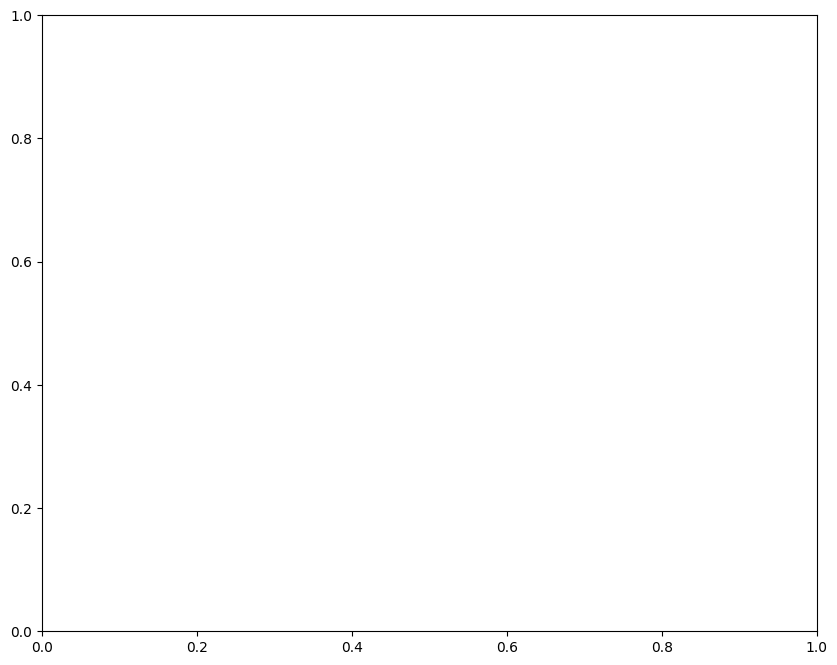

In [ ]:


# Plotting predictions
fig, ax = plt.subplots(figsize=(10, 8))
for name, y_pred in prediction_list.items():
    ax.scatter(y_test_sliced, y_pred_sliced, label=f'{name} (R2 Score: {results[name]["R2 Score"]:.2f})')
    ax.plot([y_test_sliced.min(), y_test_sliced.max()], [y_test_sliced.min(), y_test_sliced.max()], 'k--', lw=4)
    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.legend()
    plt.show()

#prediction_df = pd.DataFrame(prediction, index=X_test.index)
#prediction_df.to_csv('/content/drive/MyDrive/Akshar ML Project/Predicted_Prices.csv')

#print("Results and predictions saved successfully.")


**Hyperparameter Tuning Section ***

Old Values:

Linear Regression Mean Squared Error: 1.4173718034236456e+27

Decision Tree MeanSquared Error: 257.32591496149615

Random Forest Mean Squared Error: 224.22584954511737

Gradient Boosting Mean Squared Error: 262.8348591266825

SVR Mean Squared Error: 1072.4046156397167


Tuning Hyperparameters for Linear Regression...


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Linear Regression Best Parameters: {}
Linear Regression Best Score: -3.0124208611499803e+27
Tuning Hyperparameters for Decision Tree...
Decision Tree Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Decision Tree Best Score: -212.90423386300898
Tuning Hyperparameters for Random Forest...
Random Forest Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Random Forest Best Score: -202.52841658548172
Tuning Hyperparameters for Gradient Boosting...
Gradient Boosting Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Gradient Boosting Best Score: -163.04751890110984
Tuning Hyperparameters for SVR...
SVR Best Parameters: {'C': 10, 'epsilon': 1, 'kernel': 'linear'}
SVR Best Score: -218.00251152225664
Linear Regression Mean Squared Error: 1.4173718034236456e+27
Decision Tree Mean Squared Error: 230.5942386688669
Random Forest Mean Squared Error: 226.7416757524237
Gra

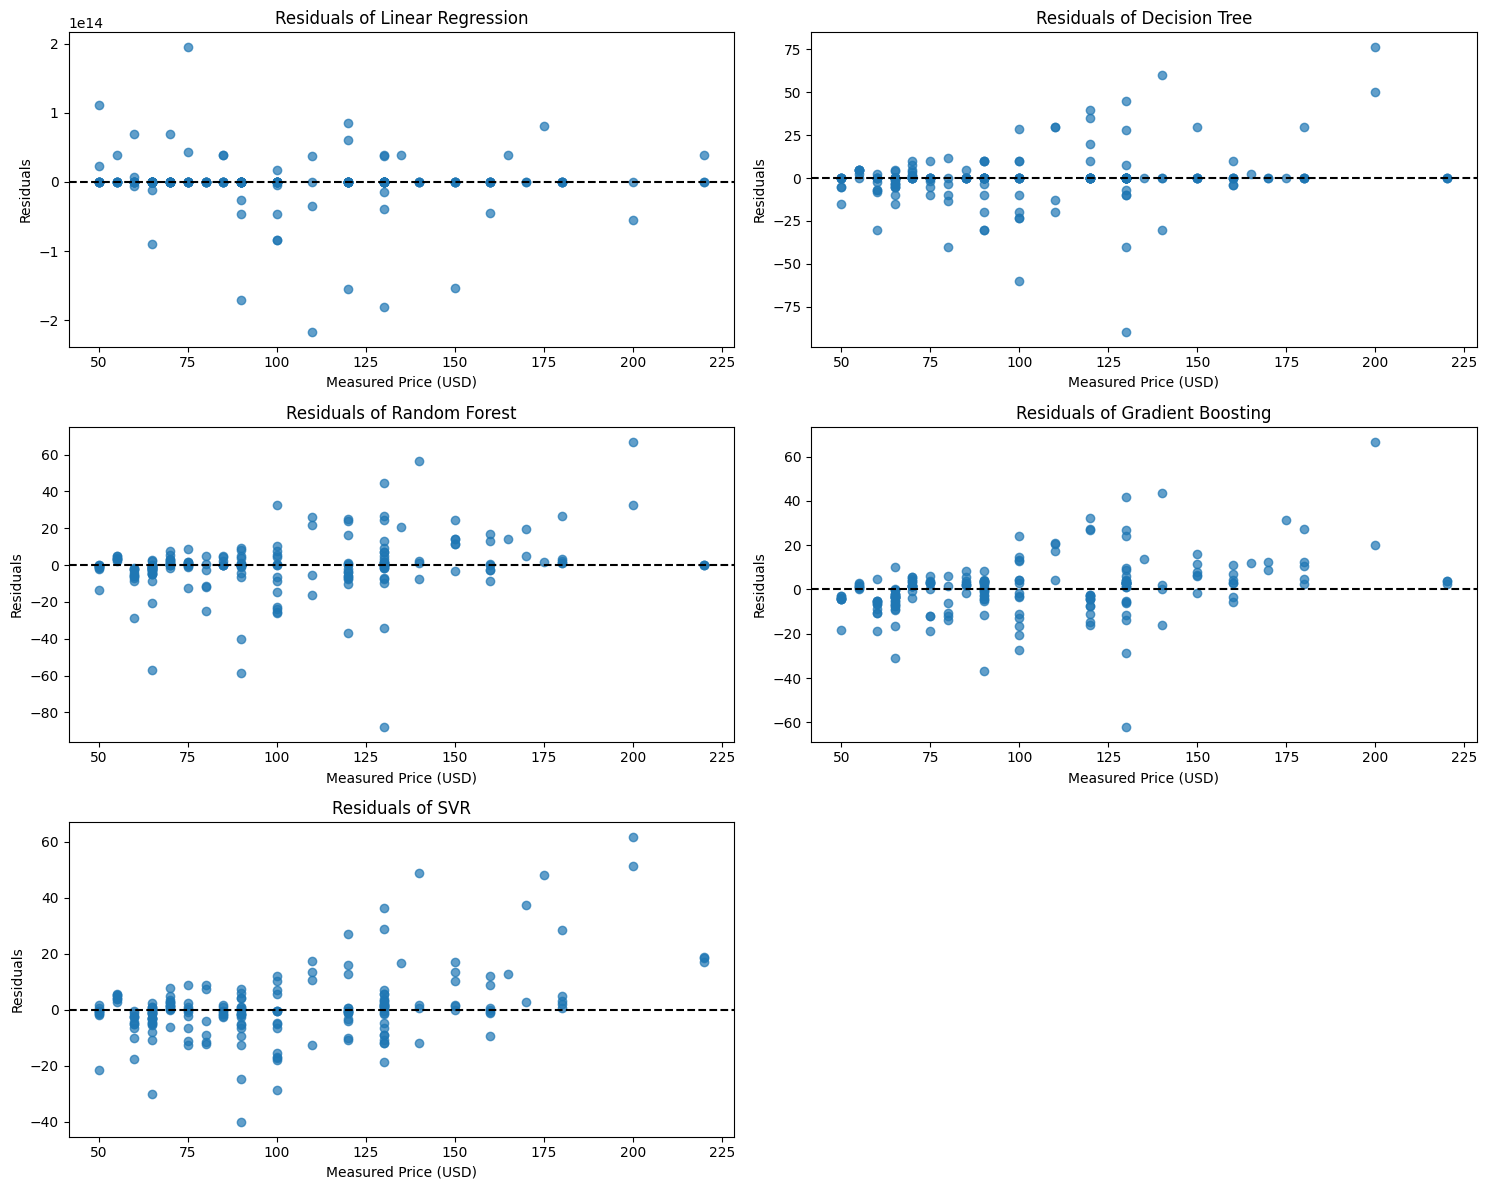

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error


# Assuming the DataFrame is already loaded into 'data'

# Clean the 'Price (USD)' column
data['Price (USD)'] = data['Price (USD)'].replace('[\$,]', '', regex=True).astype(float)

# Encode categorical variables using OneHotEncoder
categorical_columns = ['Brand', 'Model', 'Type', 'Gender', 'Size', 'Color', 'Material']
encoder = OneHotEncoder(sparse=False)
encoded_features = encoder.fit_transform(data[categorical_columns])

# Convert the encoded features to a DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

# Combine encoded features with the 'Price (USD)' column
encoded_df['Price (USD)'] = data['Price (USD)']


# Split the data into training and testing sets
X = encoded_df.drop('Price (USD)', axis=1)
y = encoded_df['Price (USD)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Define Paramater Grids
param_grids = {
    'Linear Regression': {},
    'Decision Tree': {'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10], 'min_samples_leaf':[1, 2, 4]},
    'Random Forest': {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20, 30],'min_samples_split': [2, 5, 10], 'min_samples_leaf':[1, 2, 4]},
    'Gradient Boosting': {'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample':[.7, .8, .9]},
    'SVR': {'C': [0.1, 1, 10], 'epsilon': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']}
}




# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR()
}

#Dictionary to Hold the Best Estimators
best_estimators = {}

#Perform Grid Search Cross Evaluation (CV) for Each Model
for name, model in models.items():
    print(f"Tuning Hyperparameters for {name}...")
    param_grid = param_grids[name]
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs = -1)
    grid_search.fit(X_train, y_train)
    best_estimators[name] = grid_search.best_estimator_
    print(f"{name} Best Parameters: {grid_search.best_params_}")
    print(f"{name} Best Score: {grid_search.best_score_}")


#Train and evaluate models with the Best Parameters, storing predictions

predictions = {}
for name, model in best_estimators.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    print(f"{name} Mean Squared Error: {mse}")

# Define number of subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

# Plot Residuals for each model
for idx, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test - y_pred
    axes[idx].scatter(y_test, residuals, alpha=0.7)
    axes[idx].axhline(y=0, color='black', linestyle='--')
    axes[idx].set_xlabel('Measured Price (USD)')
    axes[idx].set_ylabel('Residuals')
    axes[idx].set_title(f'Residuals of {name}')

# Hide the empty subplot
axes[-1].axis('off')
plt.tight_layout()
plt.show()

